In [1]:
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.optim as optim
from sklearn.metrics import classification_report

from src import (
    LipSequenceDataset, SequenceAugmentation, Conv3DNet, ImprovedConv3DNet,
    validate, train_model, GradCAM3D, BalancedFocalLoss,
    setup_device, calculate_class_weights, create_data_loaders, print_summary,
    plot_training_curves, plot_confusion_matrices, visualize_gradcam, visualize_model_architecture,
    DATA_DIR, TRAIN_SUBJECTS, VAL_SUBJECTS, TEST_SUBJECTS, WARMUP_EPOCHS,
    WINDOW_SIZES, BATCH_SIZE, NUM_EPOCHS, LEARNING_RATE, NUM_CLASSES, CLASS_NAMES,
    WEIGHT_DECAY, EARLY_STOPPING_PATIENCE, MAX_GRAD_NORM, FOCAL_LOSS_GAMMA
)

print("✓ All imports successful")

✓ All imports successful


In [2]:
device = setup_device(seed=42)
print(f"✓ Using device: {device}")

# Display GPU information if available
if torch.cuda.is_available():
    print(f"✓ GPU: {torch.cuda.get_device_name(0)}")
    print(f"✓ CUDA Version: {torch.version.cuda}")
    print(f"✓ GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
else:
    print("⚠ CUDA not available, using CPU (training will be slower)")

✓ Using device: cuda
✓ GPU: NVIDIA GeForce RTX 3090
✓ CUDA Version: 12.4
✓ GPU Memory: 24.00 GB


## 2. Model Architecture


In [3]:
sample_model = Conv3DNet(num_classes=NUM_CLASSES, window_size=9)
visualize_model_architecture(sample_model, input_shape=(1, 3, 9, 100, 180))

Model Architecture:
Conv3DNet(
  (conv1): Sequential(
    (0): Conv3d(3, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout3d(p=0.15, inplace=False)
    (4): MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2), padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): BatchNorm3d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout3d(p=0.25, inplace=False)
    (4): MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2), padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv3d(128, 256, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): BatchNorm3d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
 

## 3. Training

Train models for different window sizes (5, 7, 9).


In [4]:
results = {}

for window_size in WINDOW_SIZES:
    print(f"\n{'='*60}")
    print(f"Training with window_size = {window_size}")
    print(f"{'='*60}\n")
    
    # Create datasets
    train_dataset = LipSequenceDataset(DATA_DIR, TRAIN_SUBJECTS, window_size=window_size, transform=SequenceAugmentation(p=0.5), mode='train')
    val_dataset = LipSequenceDataset(DATA_DIR, VAL_SUBJECTS, window_size=window_size, transform=None, mode='val')
    test_dataset = LipSequenceDataset(DATA_DIR, TEST_SUBJECTS, window_size=window_size, transform=None, mode='test')
    
    # Calculate class weights and create data loaders
    class_weights, class_weights_tensor = calculate_class_weights(train_dataset.labels, NUM_CLASSES)
    print(f"Class weights: {class_weights}")
    
    train_loader, val_loader, test_loader = create_data_loaders(train_dataset, val_dataset, test_dataset, class_weights, BATCH_SIZE)
    
    # Initialize model
    model = ImprovedConv3DNet(num_classes=NUM_CLASSES, window_size=window_size).to(device)
    criterion = BalancedFocalLoss(alpha=class_weights_tensor.to(device), gamma=FOCAL_LOSS_GAMMA)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    
    # Train model
    history = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, NUM_EPOCHS, device, patience=EARLY_STOPPING_PATIENCE, max_grad_norm=MAX_GRAD_NORM, warmup_epochs=WARMUP_EPOCHS)
    
    # Evaluate on test set
    model.load_state_dict(history['best_model_state'])
    test_loss, test_acc, test_preds, test_labels = validate(model, test_loader, criterion, device)
    
    print(f'\nTest Results for window_size={window_size}:')
    print(f'Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%')
    print('\nClassification Report:')
    print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES))
    
    results[window_size] = {**history, 'test_acc': test_acc, 'test_loss': test_loss, 'test_preds': test_preds, 'test_labels': test_labels, 'model': model}
    print(f"\n✓ Completed training for window_size={window_size}\n")


Training with window_size = 5

Created 3456 sequences for train set (window_size=5)
Class distribution: Counter({0: 1516, 4: 484, 3: 463, 2: 425, 5: 313, 1: 255})
Created 573 sequences for val set (window_size=5)
Class distribution: Counter({0: 246, 1: 69, 3: 67, 5: 65, 2: 64, 4: 62})
Created 1060 sequences for test set (window_size=5)
Class distribution: Counter({0: 548, 2: 124, 1: 110, 3: 100, 5: 92, 4: 86})
Class weights: {0: 0.37994722955145116, 1: 2.2588235294117647, 2: 1.3552941176470588, 3: 1.244060475161987, 4: 1.1900826446280992, 5: 1.840255591054313}


Epoch 1/60 [Training]: 100%|██████████| 108/108 [00:27<00:00,  3.98it/s, loss=1.7405, acc=18.75%]


Train Loss: 1.9452, Train Acc: 18.75%
Val Loss: 1.3850, Val Acc: 15.36%
✓ New best validation accuracy: 15.36%


Epoch 2/60 [Training]: 100%|██████████| 108/108 [00:26<00:00,  4.01it/s, loss=1.5913, acc=24.10%]


Train Loss: 1.8065, Train Acc: 24.10%
Val Loss: 1.2705, Val Acc: 19.72%
✓ New best validation accuracy: 19.72%


...

Train Loss: 1.1465, Train Acc: 42.35%
Val Loss: 0.9063, Val Acc: 30.88%


Epoch 27/60 [Training]: 100%|██████████| 54/54 [00:25<00:00,  2.12it/s, loss=1.4651, acc=42.82%]


Train Loss: 1.0943, Train Acc: 42.82%
Val Loss: 0.7949, Val Acc: 31.58%


Epoch 28/60 [Training]: 100%|██████████| 54/54 [00:25<00:00,  2.10it/s, loss=0.8891, acc=41.71%]


Train Loss: 1.1486, Train Acc: 41.71%
Val Loss: 0.8917, Val Acc: 28.77%
Early stopping at epoch 28

Test Results for window_size=9:
Test Loss: 1.0544, Test Acc: 20.11%

Classification Report:
                 precision    recall  f1-score   support

Silence/Neutral       1.00      0.01      0.01       273
            /A/       0.47      0.71      0.56        52
            /I/       0.31      0.26      0.28        57
            /U/       0.12      0.22      0.15        50
            /E/       0.55      0.14      0.22        44
            /O/       0.12      0.69      0.20        51

       accuracy                           0.20       527
      macro avg       0.43      0.34      0.24       527
   weighted avg       0.67      0.20      0.15       527


✓ Completed training for window_size=9



## 4. Results Visualization


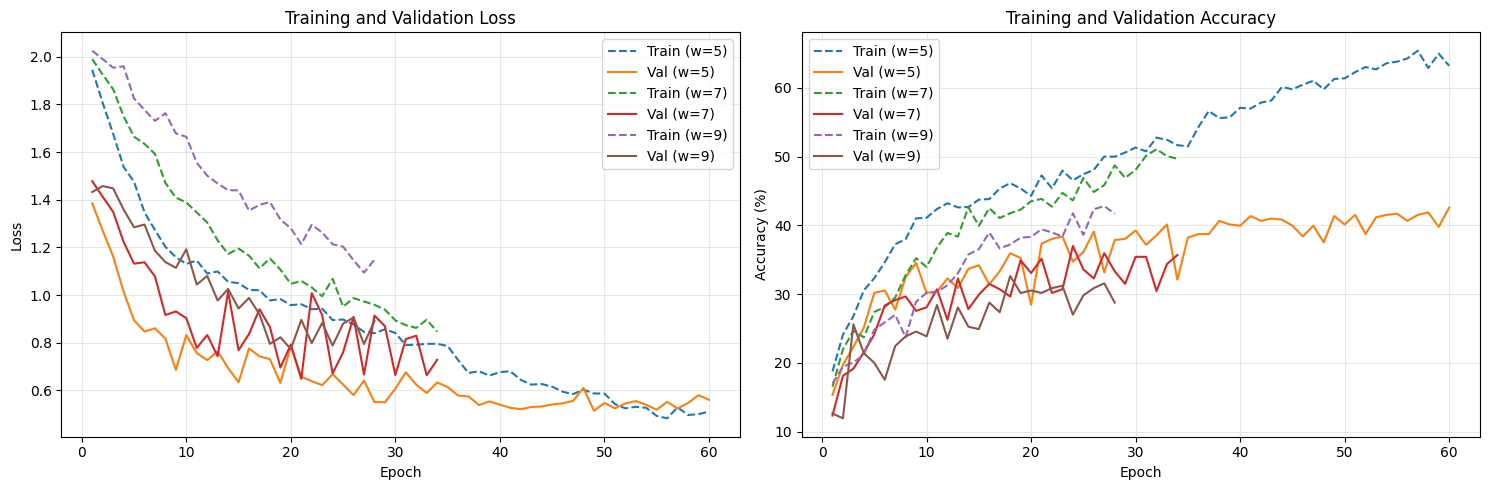

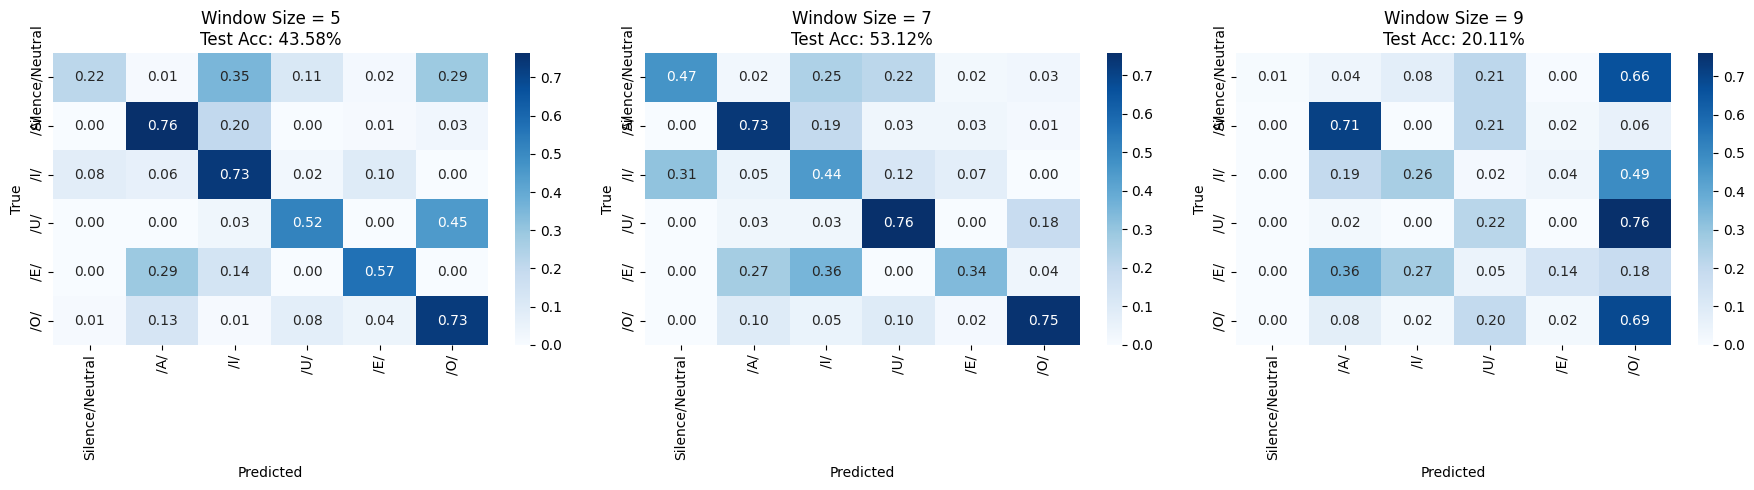


SUMMARY OF RESULTS
Window Size     Val Acc (%)     Test Acc (%)    Test Loss      
------------------------------------------------------------
5               42.58           43.58           0.7364         
7               37.01           53.12           0.7445         
9               32.63           20.11           1.0544         
✓ Best model: window_size=7 with test accuracy=53.12%



In [5]:
plot_training_curves(results, WINDOW_SIZES)
plot_confusion_matrices(results, WINDOW_SIZES, CLASS_NAMES)
print_summary(results, WINDOW_SIZES, CLASS_NAMES)

## 5. Grad-CAM Visualization

Visualizing with best model (window_size=7, test_acc=53.12%)
Created 704 sequences for test set (window_size=7)
Class distribution: Counter({0: 371, 2: 81, 1: 67, 3: 66, 5: 63, 4: 56})


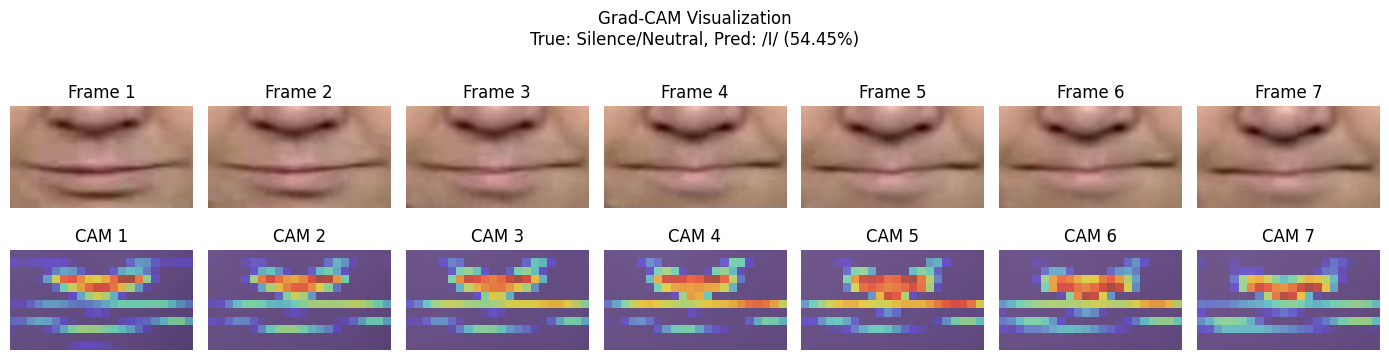

In [6]:
if results:
    best_window_size = max(results.keys(), key=lambda k: results[k]['test_acc'])
    print(f"Visualizing with best model (window_size={best_window_size}, test_acc={results[best_window_size]['test_acc']:.2f}%)")
    
    model = results[best_window_size]['model']
    
    # Select appropriate layer for GradCAM based on model type
    if hasattr(model, 'conv4'):
        target_layer = model.conv4[0]  # Conv3DNet
    elif hasattr(model, 'res_block3'):
        target_layer = model.res_block3[0]  # ImprovedConv3DNet
    else:
        # Fallback: find last Conv3d layer
        conv_layers = [m for m in model.modules() if isinstance(m, torch.nn.Conv3d)]
        if conv_layers:
            target_layer = conv_layers[-1]
        else:
            raise ValueError("No Conv3d layer found in model for GradCAM")
    
    gradcam = GradCAM3D(model, target_layer)
    
    test_dataset = LipSequenceDataset(DATA_DIR, TEST_SUBJECTS, window_size=best_window_size, transform=None, mode='test')
    if len(test_dataset) > 0:
        sample_sequence, sample_label = test_dataset[0]
        sample_sequence = sample_sequence.unsqueeze(0).to(device)
        visualize_gradcam(model, gradcam, sample_sequence, sample_label, best_window_size, CLASS_NAMES)
    else:
        print("⚠ No test samples available.")
else:
    print("⚠ No results available. Please run training first.")